# AI012 LOF Optimization

Unsupervised Local Outlier Factor optimization for PHOENIX AI012 anomaly detection. This notebook uses the AI012 Role A dataset, shared feature engineering, config-driven paths, score distribution thresholding, TensorBoard logging, and model-specific reports.

## Supervised vs Unsupervised Evaluation

This notebook defaults to unsupervised evaluation because LOF can train and tune thresholds from anomaly score distributions without labels. Supervised metrics such as precision, recall, F1, ROC-AUC, PR-AUC, false positive rate, false negative rate, ROC curves, PR curves, and confusion matrices require trusted labels and are intentionally disabled unless the config is changed later. The active evaluation reports anomaly rate, score summary statistics, quantile threshold behavior, and detection stability.

In [1]:
from pathlib import Path
import json
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from torch.utils.tensorboard import SummaryWriter
except Exception:
    SummaryWriter = None


def find_ai012_root(start=None):
    start = (start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if path.name == "ai012-anomaly":
            return path
        candidate = path / "ai-ml" / "models" / "ai012-anomaly"
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate ai-ml/models/ai012-anomaly")


AI012_ROOT = find_ai012_root()
SRC_DIR = AI012_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from features.feature_selector import FeatureSelector

sns.set_theme(style="whitegrid")
AI012_ROOT

WindowsPath('C:/Users/koolg/OneDrive - Deakin University/PHOENIX/Phoenix Github Repo/ai-ml/models/ai012-anomaly')

In [2]:
MODEL_NAME = "lof"
CONFIG_PATH = AI012_ROOT / "lof" / "configs" / "lof_config.yaml"

with CONFIG_PATH.open("r", encoding="utf-8") as handle:
    config = yaml.safe_load(handle)


def resolve_config_path(value):
    if not value:
        return None
    path = Path(value)
    if path.is_absolute():
        return path
    return (CONFIG_PATH.parent / path).resolve()


dataset_path = resolve_config_path(config["dataset"]["path"])
reports_dir = resolve_config_path(config["outputs"]["reports_dir"])
graphs_dir = resolve_config_path(config["outputs"]["graphs_dir"])
checkpoints_dir = resolve_config_path(config["outputs"]["checkpoints_dir"])
logs_dir = resolve_config_path(config["outputs"]["logs_dir"])
tb_root = resolve_config_path(config["training"]["tensorboard_log_dir"])
tb_run_dir = tb_root / config["training"].get("tensorboard_run_name", MODEL_NAME)

for directory in [reports_dir, graphs_dir, checkpoints_dir, logs_dir, tb_run_dir]:
    directory.mkdir(parents=True, exist_ok=True)

assert config["dataset"].get("evaluation_mode") == "unsupervised"
assert config["dataset"].get("target_column") is None
assert dataset_path.exists(), dataset_path

print("Dataset:", dataset_path)
print("Reports:", reports_dir)
print("Graphs:", graphs_dir)
print("TensorBoard:", tb_run_dir)

Dataset: C:\Users\koolg\OneDrive - Deakin University\PHOENIX\Phoenix Github Repo\ai-ml\datasets\anomaly_detection_hourly_2020_2024.csv
Reports: C:\Users\koolg\OneDrive - Deakin University\PHOENIX\Phoenix Github Repo\ai-ml\models\ai012-anomaly\lof\reports
Graphs: C:\Users\koolg\OneDrive - Deakin University\PHOENIX\Phoenix Github Repo\ai-ml\models\ai012-anomaly\lof\outputs\graphs
TensorBoard: C:\Users\koolg\OneDrive - Deakin University\PHOENIX\Phoenix Github Repo\ai-ml\models\ai012-anomaly\logs\tensorboard\ai012_anomaly_optimization\lof


In [3]:
df_raw = pd.read_csv(dataset_path, low_memory=False)
df = FeatureSelector(df_raw).create_features()

drop_columns = set(config["preprocessing"].get("drop_columns", []))
drop_columns.update({"label", "is_anomaly", "anomaly_label", "anomaly_flag", "anomaly_score", "anomaly_rank"})

selected_features = config["preprocessing"].get("selected_features") or []
if selected_features:
    feature_columns = [col for col in selected_features if col in df.columns and col not in drop_columns]
else:
    feature_columns = [col for col in df.select_dtypes(include=[np.number]).columns if col not in drop_columns]

X = df[feature_columns].replace([np.inf, -np.inf], np.nan)

seed = config["dataset"].get("random_seed", 42)
train_size = config["dataset"].get("train_split", 0.7)
val_size = config["dataset"].get("val_split", 0.15)
test_size = config["dataset"].get("test_split", 0.15)

X_train, X_tmp = train_test_split(X, train_size=train_size, shuffle=True, random_state=seed)
relative_val_size = val_size / (val_size + test_size)
X_val, X_test = train_test_split(X_tmp, train_size=relative_val_size, shuffle=True, random_state=seed)

preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy=config["preprocessing"].get("missing_value_strategy", "median"))),
    ("scaler", StandardScaler()),
])

X_train_scaled = preprocessor.fit_transform(X_train)
X_val_scaled = preprocessor.transform(X_val)
X_test_scaled = preprocessor.transform(X_test)

print("Raw shape:", df_raw.shape)
print("Feature shape:", X.shape)
print("Split sizes:", len(X_train), len(X_val), len(X_test))

Raw shape: (169539, 45)
Feature shape: (169539, 50)
Split sizes: 118677 25431 25431


In [4]:
params = config["model"]["hyperparameters"]
model = LocalOutlierFactor(
    n_neighbors=params.get("n_neighbors", 35),
    contamination=params.get("contamination", 0.07),
    metric=params.get("metric", "minkowski"),
    p=params.get("p", 2),
    novelty=params.get("novelty", True),
    algorithm=params.get("algorithm", "auto"),
    leaf_size=params.get("leaf_size", 30),
    n_jobs=params.get("n_jobs", -1),
)

model.fit(X_train_scaled)
val_scores = -model.decision_function(X_val_scaled)
test_scores = -model.decision_function(X_test_scaled)
threshold_quantile = 1.0 - config["evaluation"].get("default_contamination", 0.07)
threshold = float(np.quantile(val_scores, threshold_quantile))
test_flags = (test_scores >= threshold).astype(int)

checkpoint = {
    "model": model,
    "preprocessor": preprocessor,
    "feature_columns": feature_columns,
    "threshold": threshold,
    "config": config,
}
checkpoint_path = checkpoints_dir / "lof_best.pkl"
joblib.dump(checkpoint, checkpoint_path)

print("Threshold:", threshold)
print("Test anomaly rate:", test_flags.mean())
print("Checkpoint:", checkpoint_path)

Threshold: 0.006245648362731328
Test anomaly rate: 0.07156619873382879
Checkpoint: C:\Users\koolg\OneDrive - Deakin University\PHOENIX\Phoenix Github Repo\ai-ml\models\ai012-anomaly\lof\outputs\checkpoints\lof_best.pkl


In [5]:
def score_iqr(values):
    q75, q25 = np.percentile(values, [75, 25])
    return float(q75 - q25)


def stability_from_scores(values, contamination, iterations=10, sample_fraction=0.8, seed=42):
    rng = np.random.default_rng(seed)
    rates = []
    values = np.asarray(values)
    sample_size = max(10, int(len(values) * sample_fraction))
    for _ in range(iterations):
        sample = rng.choice(values, size=sample_size, replace=False)
        sample_threshold = np.quantile(sample, 1.0 - contamination)
        rates.append(float((sample >= sample_threshold).mean()))
    mean_rate = float(np.mean(rates))
    std_rate = float(np.std(rates))
    return float(np.clip(1.0 - (std_rate / (mean_rate + 1e-9)), 0.0, 1.0))


contamination = config["evaluation"].get("default_contamination", 0.07)
stability_cfg = config["evaluation"].get("stability", {})
stability_score = stability_from_scores(
    test_scores,
    contamination=contamination,
    iterations=stability_cfg.get("bootstrap_iterations", 10),
    sample_fraction=stability_cfg.get("sample_fraction", 0.8),
    seed=seed,
)

metrics = {
    "model": MODEL_NAME,
    "evaluation_mode": "unsupervised",
    "n_rows": int(len(X)),
    "n_features": int(len(feature_columns)),
    "threshold": threshold,
    "threshold_quantile": threshold_quantile,
    "anomaly_rate": float(test_flags.mean()),
    "score_mean": float(np.mean(test_scores)),
    "score_std": float(np.std(test_scores)),
    "score_iqr": score_iqr(test_scores),
    "stability_score": stability_score,
    "precision": None,
    "recall": None,
    "f1": None,
    "roc_auc": None,
    "pr_auc": None,
    "false_positive_rate": None,
    "false_negative_rate": None,
}

results_path = resolve_config_path(config["outputs"]["results_file"])
with results_path.open("w", encoding="utf-8") as handle:
    json.dump(metrics, handle, indent=2)

scores_df = pd.DataFrame({"anomaly_score": test_scores, "anomaly_flag": test_flags})
scores_df.to_csv(resolve_config_path(config["outputs"]["scores_file"]), index=False)

quantiles = np.linspace(0.50, 0.995, config["evaluation"].get("threshold_grid_size", 101))
threshold_df = pd.DataFrame([
    {
        "threshold_quantile": float(q),
        "threshold": float(np.quantile(val_scores, q)),
        "anomaly_rate": float((test_scores >= np.quantile(val_scores, q)).mean()),
    }
    for q in quantiles
])
threshold_df.to_csv(resolve_config_path(config["outputs"]["threshold_file"]), index=False)

metrics

{'model': 'lof',
 'evaluation_mode': 'unsupervised',
 'n_rows': 169539,
 'n_features': 50,
 'threshold': 0.006245648362731328,
 'threshold_quantile': 0.9299999999999999,
 'anomaly_rate': 0.07156619873382879,
 'score_mean': -0.158393917299703,
 'score_std': 0.12047393987729417,
 'score_iqr': 0.09728117508723577,
 'stability_score': 1.0,
 'precision': None,
 'recall': None,
 'f1': None,
 'roc_auc': None,
 'pr_auc': None,
 'false_positive_rate': None,
 'false_negative_rate': None}

In [6]:
# Supervised threshold selection and held-out evaluation against Role C labels.
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

labels_path = AI012_ROOT / "data" / "processed" / "anomaly_labels_v1.csv"
if not labels_path.exists():
    from labeling.label_builder import run as build_labels

    labels_df = build_labels(dataset_path=str(dataset_path), save=False)
    labels_path.parent.mkdir(parents=True, exist_ok=True)
    labels_df.to_csv(labels_path, index=False)
else:
    labels_df = pd.read_csv(labels_path)

if len(labels_df) != len(df_raw):
    raise ValueError(f"Label row count {len(labels_df)} does not match dataset row count {len(df_raw)}")
if "anomaly_flag" not in labels_df.columns:
    raise ValueError("Expected anomaly_flag column in Role C labels")

y_all = labels_df["anomaly_flag"].astype(int)
y_val = y_all.loc[X_val.index].to_numpy()
y_test = y_all.loc[X_test.index].to_numpy()

supervised_threshold_rows = []
for _, row in threshold_df.iterrows():
    candidate_threshold = float(row["threshold"])
    val_flags = (val_scores >= candidate_threshold).astype(int)
    supervised_threshold_rows.append({
        "threshold_quantile": float(row["threshold_quantile"]),
        "threshold": candidate_threshold,
        "val_precision": precision_score(y_val, val_flags, zero_division=0),
        "val_recall": recall_score(y_val, val_flags, zero_division=0),
        "val_f1": f1_score(y_val, val_flags, zero_division=0),
        "val_anomaly_rate": float(val_flags.mean()),
    })

supervised_threshold_df = pd.DataFrame(supervised_threshold_rows)
supervised_threshold_df = supervised_threshold_df.sort_values(
    ["val_f1", "val_precision", "val_recall"], ascending=False
).reset_index(drop=True)
supervised_threshold = float(supervised_threshold_df.loc[0, "threshold"])
supervised_threshold_quantile = float(supervised_threshold_df.loc[0, "threshold_quantile"])
supervised_test_flags = (test_scores >= supervised_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, supervised_test_flags, labels=[0, 1]).ravel()

def safe_auc(metric_func, y_true, y_score):
    return float(metric_func(y_true, y_score)) if len(np.unique(y_true)) > 1 else None

supervised_metrics = {
    "model": MODEL_NAME,
    "evaluation_mode": "supervised",
    "supervision_type": "role_c_threshold_selection",
    "label_source": str(labels_path.relative_to(AI012_ROOT)),
    "n_rows": int(len(X)),
    "n_features": int(len(feature_columns)),
    "test_rows": int(len(y_test)),
    "label_anomaly_rate": float(y_test.mean()),
    "threshold": supervised_threshold,
    "threshold_quantile": supervised_threshold_quantile,
    "anomaly_rate": float(supervised_test_flags.mean()),
    "score_mean": float(np.mean(test_scores)),
    "score_std": float(np.std(test_scores)),
    "score_iqr": score_iqr(test_scores),
    "stability_score": stability_score,
    "precision": precision_score(y_test, supervised_test_flags, zero_division=0),
    "recall": recall_score(y_test, supervised_test_flags, zero_division=0),
    "f1": f1_score(y_test, supervised_test_flags, zero_division=0),
    "roc_auc": safe_auc(roc_auc_score, y_test, test_scores),
    "pr_auc": safe_auc(average_precision_score, y_test, test_scores),
    "false_positive_rate": float(fp / (fp + tn)) if (fp + tn) else None,
    "false_negative_rate": float(fn / (fn + tp)) if (fn + tp) else None,
    "true_negative": int(tn),
    "false_positive": int(fp),
    "false_negative": int(fn),
    "true_positive": int(tp),
}
if "epochs" in globals():
    supervised_metrics["training_epochs"] = int(epochs)
if "best_epoch" in globals():
    supervised_metrics["best_epoch"] = int(best_epoch)
if "best_val_loss" in globals():
    supervised_metrics["best_val_loss"] = float(best_val_loss)

base_results_path = resolve_config_path(config["outputs"]["results_file"])
supervised_results_path = base_results_path.with_name(f"{MODEL_NAME}_supervised_metrics.json")
with supervised_results_path.open("w", encoding="utf-8") as handle:
    json.dump(supervised_metrics, handle, indent=2)

base_scores_path = resolve_config_path(config["outputs"]["scores_file"])
supervised_scores_path = base_scores_path.with_name(f"{MODEL_NAME}_supervised_scores.csv")
pd.DataFrame({
    "anomaly_score": test_scores,
    "anomaly_flag": supervised_test_flags,
    "label_anomaly_flag": y_test,
}).to_csv(supervised_scores_path, index=False)

base_threshold_path = resolve_config_path(config["outputs"]["threshold_file"])
supervised_threshold_path = base_threshold_path.with_name(f"{MODEL_NAME}_supervised_threshold_tuning.csv")
supervised_threshold_df.to_csv(supervised_threshold_path, index=False)

if config["training"].get("tensorboard_enabled", False) and SummaryWriter is not None:
    supervised_tb_run_dir = tb_run_dir.parent / f"{config['training'].get('tensorboard_run_name', MODEL_NAME)}_supervised"
    supervised_tb_run_dir.mkdir(parents=True, exist_ok=True)
    writer = SummaryWriter(log_dir=str(supervised_tb_run_dir))
    supervised_tensorboard_scalars = {
        "dataset/n_rows": "n_rows",
        "dataset/n_features": "n_features",
        "labels/anomaly_rate": "label_anomaly_rate",
        "metrics/anomaly_rate": "anomaly_rate",
        "metrics/precision": "precision",
        "metrics/recall": "recall",
        "metrics/f1": "f1",
        "metrics/roc_auc": "roc_auc",
        "metrics/pr_auc": "pr_auc",
        "metrics/false_positive_rate": "false_positive_rate",
        "metrics/false_negative_rate": "false_negative_rate",
        "metrics/score_mean": "score_mean",
        "metrics/score_std": "score_std",
        "metrics/score_iqr": "score_iqr",
        "metrics/stability_score": "stability_score",
        "threshold/value": "threshold",
        "threshold/quantile": "threshold_quantile",
    }
    for idx, row in supervised_threshold_df.sort_values("threshold_quantile").reset_index(drop=True).iterrows():
        writer.add_scalar("tuning/val_precision", row["val_precision"], idx)
        writer.add_scalar("tuning/val_recall", row["val_recall"], idx)
        writer.add_scalar("tuning/val_f1", row["val_f1"], idx)
        writer.add_scalar("tuning/val_anomaly_rate", row["val_anomaly_rate"], idx)
        writer.add_scalar("tuning/threshold", row["threshold"], idx)
        writer.add_scalar("tuning/threshold_quantile", row["threshold_quantile"], idx)
    for tag, metric_name in supervised_tensorboard_scalars.items():
        value = supervised_metrics.get(metric_name)
        if value is not None:
            writer.add_scalar(tag, value, 0)
    writer.close()
    print("Supervised TensorBoard logs written to:", supervised_tb_run_dir)

supervised_metrics


Supervised TensorBoard logs written to: C:\Users\koolg\OneDrive - Deakin University\PHOENIX\Phoenix Github Repo\ai-ml\models\ai012-anomaly\logs\tensorboard\ai012_anomaly_optimization\lof_supervised


{'model': 'lof',
 'evaluation_mode': 'supervised',
 'supervision_type': 'role_c_threshold_selection',
 'label_source': 'data\\processed\\anomaly_labels_v1.csv',
 'n_rows': 169539,
 'n_features': 50,
 'test_rows': 25431,
 'label_anomaly_rate': 0.06912822932641265,
 'threshold': -0.13748506755701959,
 'threshold_quantile': 0.7376,
 'anomaly_rate': 0.2667217175887696,
 'score_mean': -0.158393917299703,
 'score_std': 0.12047393987729417,
 'score_iqr': 0.09728117508723577,
 'stability_score': 1.0,
 'precision': 0.13121037888839746,
 'recall': 0.5062571103526735,
 'f1': 0.2084065097763728,
 'roc_auc': 0.6979866273347894,
 'pr_auc': 0.12317795519994457,
 'false_positive_rate': 0.2489333840239936,
 'false_negative_rate': 0.4937428896473265,
 'true_negative': 17780,
 'false_positive': 5893,
 'false_negative': 868,
 'true_positive': 890}

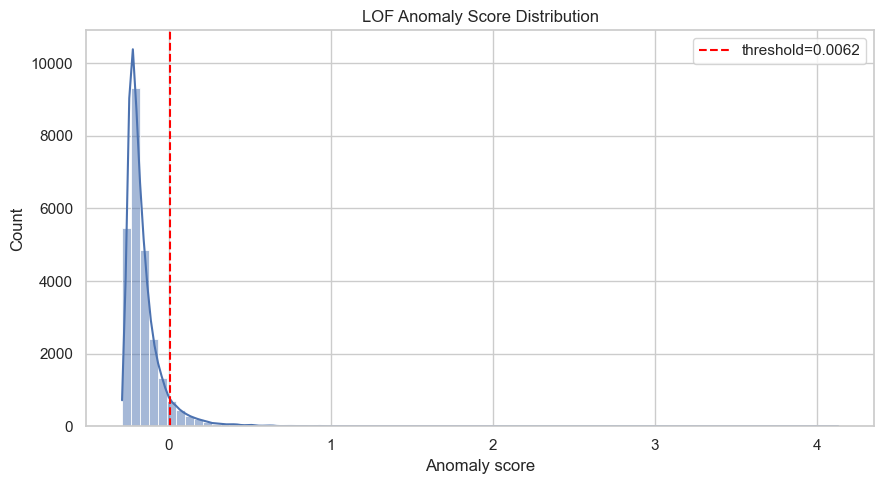

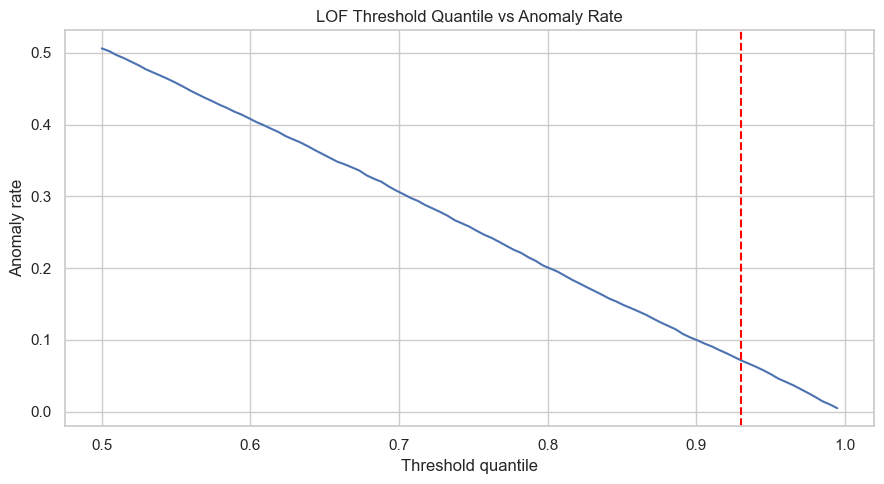

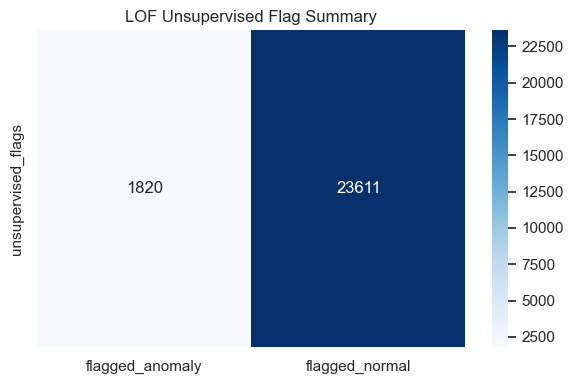

In [7]:
plt.figure(figsize=(9, 5))
sns.histplot(test_scores, bins=80, kde=True)
plt.axvline(threshold, color="red", linestyle="--", label=f"threshold={threshold:.4f}")
plt.title("LOF Anomaly Score Distribution")
plt.xlabel("Anomaly score")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig(graphs_dir / "lof_score_distribution.png", dpi=150)
plt.show()

plt.figure(figsize=(9, 5))
sns.lineplot(data=threshold_df, x="threshold_quantile", y="anomaly_rate")
plt.axvline(threshold_quantile, color="red", linestyle="--")
plt.title("LOF Threshold Quantile vs Anomaly Rate")
plt.xlabel("Threshold quantile")
plt.ylabel("Anomaly rate")
plt.tight_layout()
plt.savefig(graphs_dir / "lof_threshold_vs_anomaly_rate.png", dpi=150)
plt.show()

plt.figure(figsize=(6, 4))
sns.heatmap(pd.DataFrame([[test_flags.sum(), len(test_flags) - test_flags.sum()]], columns=["flagged_anomaly", "flagged_normal"], index=["unsupervised_flags"]), annot=True, fmt="d", cmap="Blues")
plt.title("LOF Unsupervised Flag Summary")
plt.tight_layout()
plt.savefig(graphs_dir / "lof_unsupervised_flag_summary.png", dpi=150)
plt.show()

In [8]:
if config["training"].get("tensorboard_enabled", False) and SummaryWriter is not None:
    writer = SummaryWriter(log_dir=str(tb_run_dir))
    common_tensorboard_scalars = {
        "dataset/n_rows": "n_rows",
        "dataset/n_features": "n_features",
        "metrics/anomaly_rate": "anomaly_rate",
        "metrics/score_mean": "score_mean",
        "metrics/score_std": "score_std",
        "metrics/score_iqr": "score_iqr",
        "metrics/stability_score": "stability_score",
        "threshold/value": "threshold",
        "threshold/quantile": "threshold_quantile",
    }
    threshold_tuning_scalars = ["threshold_quantile", "threshold", "anomaly_rate"]

    for idx, row in threshold_df.iterrows():
        for column in threshold_tuning_scalars:
            writer.add_scalar(f"tuning/{column}", row[column], idx)

    for tag, metric_name in common_tensorboard_scalars.items():
        value = metrics.get(metric_name)
        if value is not None:
            writer.add_scalar(tag, value, 0)

    writer.close()
    print("TensorBoard logs written to:", tb_run_dir)
else:
    print("TensorBoard logging skipped because torch SummaryWriter is unavailable or disabled.")


TensorBoard logs written to: C:\Users\koolg\OneDrive - Deakin University\PHOENIX\Phoenix Github Repo\ai-ml\models\ai012-anomaly\logs\tensorboard\ai012_anomaly_optimization\lof
